In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [7]:
df = pd.read_csv('academia_redfit.csv')
df['sexo'] = df['sexo'].str.strip().str.upper()
df['estado'] = df['estado'].str.strip().str.capitalize()
df['data_matricula'] = pd.to_datetime(df['data_matricula'])
df['evolucao_pgc'] = df['primeiro_PGC'] - df['ultimo_PGC']
def rotular_nivel(row):
    if row['estado'] == 'Sedentária':
        return 'Sedentário'
    elif row['frequencia_semanal_treino'] >= 5:
        return 'Atleta'
    else:
        return 'Ativo'

df['nivel_atividade'] = df.apply(rotular_nivel, axis=1)

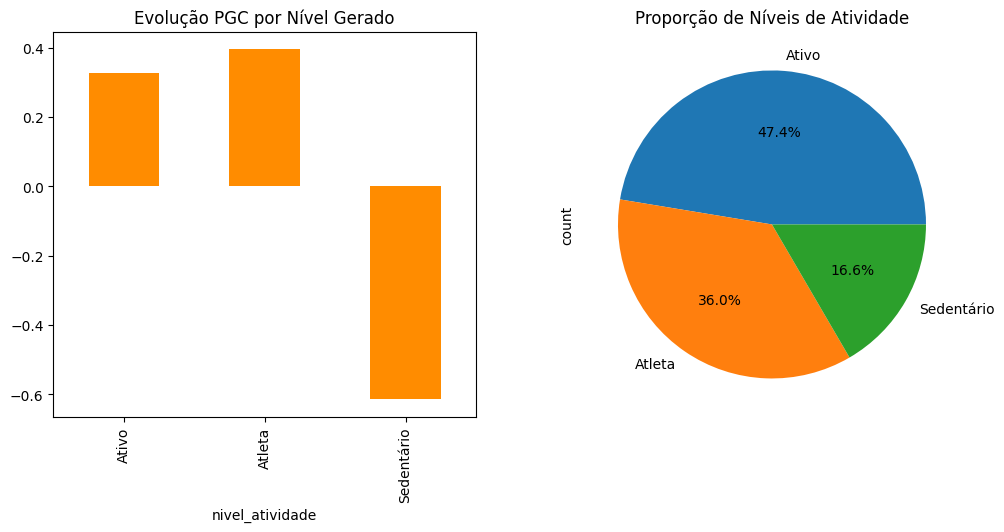

In [8]:

df.to_csv('academia_club4_limpo.csv', index=False)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df.groupby('nivel_atividade')['evolucao_pgc'].mean().plot(kind='bar', color='darkorange')
plt.title('Evolução PGC por Nível Gerado')

plt.subplot(1, 2, 2)
df['nivel_atividade'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporção de Níveis de Atividade')
plt.show()



In [9]:
X = df[['idade', 'frequencia_semanal_treino', 'tempo_medio_exercicio', 'ultimo_PGC']]
y = df['nivel_atividade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestClassifier(n_estimators=100)
modelo.fit(X_train, y_train)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, modelo.predict(X_test)))


--- Relatório de Classificação ---
              precision    recall  f1-score   support

       Ativo       1.00      1.00      1.00        84
      Atleta       1.00      1.00      1.00        80
  Sedentário       1.00      1.00      1.00        36

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

